Epoch 10/100, Loss: 1.6863
Epoch 20/100, Loss: 0.4427
Epoch 30/100, Loss: 0.1177
Epoch 40/100, Loss: 0.0672
Epoch 50/100, Loss: 0.0602
Epoch 60/100, Loss: 0.0123
Epoch 70/100, Loss: 0.0129
Epoch 80/100, Loss: 0.0214
Epoch 90/100, Loss: 0.0068
Epoch 100/100, Loss: 0.0076


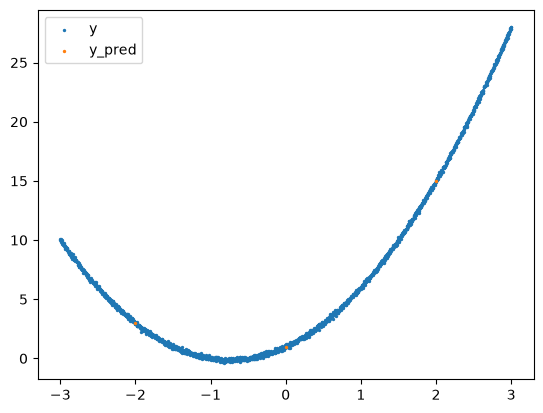

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ============ 1. 生成数据（和TensorFlow版本完全一样） ============
x = np.linspace(-3, 3, 2000).reshape(-1, 1)
y = 2*x**2 + 3*x + 1 + np.random.normal(0, 0.1, x.shape)

# 转换为PyTorch张量（float32是默认精度）
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# ============ 2. 定义模型（等价于TensorFlow的Sequential） ============
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.hidden = nn.Linear(1, 64)    # 输入1维，输出64维（等价于Dense(64)）
        self.relu = nn.ReLU()             # 激活函数
        self.output = nn.Linear(64, 1)    # 输入64维，输出1维（等价于Dense(1)）
    
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

model = MyModel()

# ============ 3. 编译模型（等价于compile） ============
criterion = nn.MSELoss()                  # 等价于 loss='mse'
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 等价于 optimizer='adam'

# ============ 4. 训练模型（等价于fit） ============
epochs = 100
batch_size = 32

# 创建DataLoader来批量处理数据（等价于batch_size）
dataset = torch.utils.data.TensorDataset(x_tensor, y_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    for batch_x, batch_y in dataloader:
        # 前向传播
        y_pred = model(batch_x)
        loss = criterion(y_pred, batch_y)
        
        # 反向传播
        optimizer.zero_grad()   # 清空之前的梯度（PyTorch需要手动做）
        loss.backward()         # 计算梯度
        optimizer.step()        # 更新参数
    
    # 可选：打印每10个epoch的loss
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# ============ 5. 预测（等价于predict） ============
model.eval()  # 切换到评估模式（对Dropout/BatchNorm有影响）
x_test = np.array([[-2], [0], [2]])
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

with torch.no_grad():  # 不计算梯度，节省内存和速度
    y_pred_tensor = model(x_test_tensor)
    y_pred = y_pred_tensor.numpy()  # 转回numpy用于绘图

# ============ 6. 绘图（和原代码完全一样） ============
plt.scatter(x, y, label='y', s=2)
plt.scatter(x_test, y_pred, label='y_pred', s=2)
plt.legend()
plt.show()
